# 🛒 Classification & Clustering
## From Purchase Intent to Customer Segments – Practical Session 4

In this session we apply two classic machine learning techniques to **real-world datasets**:

| Part | Technique | Dataset | Goal |
|---|---|---|---|
| 1–3 | **Decision Tree** | UCI Online Shoppers | Predict purchase intent |
| 4 | **k-Means Clustering** | Mall Customers | Discover customer segments |
| 6 | **Group Activity** | 4 datasets | Hands-on exploration |

## 📦 Step 0: Install & Import Libraries

In [ ]:
!pip install datasets scikit-learn --quiet

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("✅ Libraries loaded!")

✅ Libraries loaded!


## 📦 Part 1: Exploring the UCI Online Shoppers Dataset

We're using the **UCI Online Shoppers Purchasing Intention Dataset** — a real dataset from an e-commerce platform with **12,330 web sessions**.

Each row represents one visit to the website. The target variable `Purchased` tells us whether that session ended in a purchase.

> 🎯 **Task:** Load the dataset, preprocess it into clean numeric columns, and explore its structure.

In [18]:
raw_dataset = load_dataset("jlh/uci-shopper", split="train")
df_raw = raw_dataset.to_pandas()

print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head(3)

Raw dataset shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0


In [19]:
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

df = pd.DataFrame({
    'Product_Pages'    : df_raw['ProductRelated'],
    'Time_on_Site_min' : (df_raw['ProductRelated_Duration'] / 60).round(1),
    'Bounce_Rate'      : (df_raw['BounceRates'] * 100).round(1),
    'Page_Value'       : df_raw['PageValues'].round(1),
    'Special_Day'      : df_raw['SpecialDay'],
    'Is_Weekend'       : df_raw['Weekend'].astype(int),
    'Returning_Visitor': (df_raw['VisitorType'] == 'Returning_Visitor').astype(int),
    'Month'            : df_raw['Month'].map(month_map),
    'Purchased'        : df_raw['Revenue'].astype(int),
})

print(f"Processed shape: {df.shape}")
print(f"Purchase rate  : {df['Purchased'].mean():.1%}")
df.head()

Processed shape: (12330, 9)
Purchase rate  : 15.5%


,Product_Pages,Time_on_Site_min,Bounce_Rate,Page_Value,Special_Day,Is_Weekend,Returning_Visitor,Month,Purchased
0,1,0.0,20.0,0.0,0.0,0,1,2.0,0
1,2,1.1,0.0,0.0,0.0,0,1,2.0,0
2,1,0.0,20.0,0.0,0.0,0,1,2.0,0
3,2,0.0,5.0,0.0,0.0,0,1,2.0,0
4,10,10.5,2.0,0.0,0.0,1,1,2.0,0


### Column Overview

| Column | Type | Description |
|---|---|---|
| `Product_Pages` | int | Number of product-related pages visited |
| `Time_on_Site_min` | float | Total time on product pages (minutes) |
| `Bounce_Rate` | float | % of visitors who left immediately (0–100) |
| `Page_Value` | float | Average value of pages visited (higher = closer to checkout) |
| `Special_Day` | float | Proximity to a special day like Valentine's Day (0–1) |
| `Is_Weekend` | int | 1 = weekend visit, 0 = weekday |
| `Returning_Visitor` | int | 1 = returning visitor, 0 = new visitor |
| `Month` | int | Month of the session (1–12) |
| `Purchased` | int | **Target**: 1 = purchase made, 0 = no purchase |

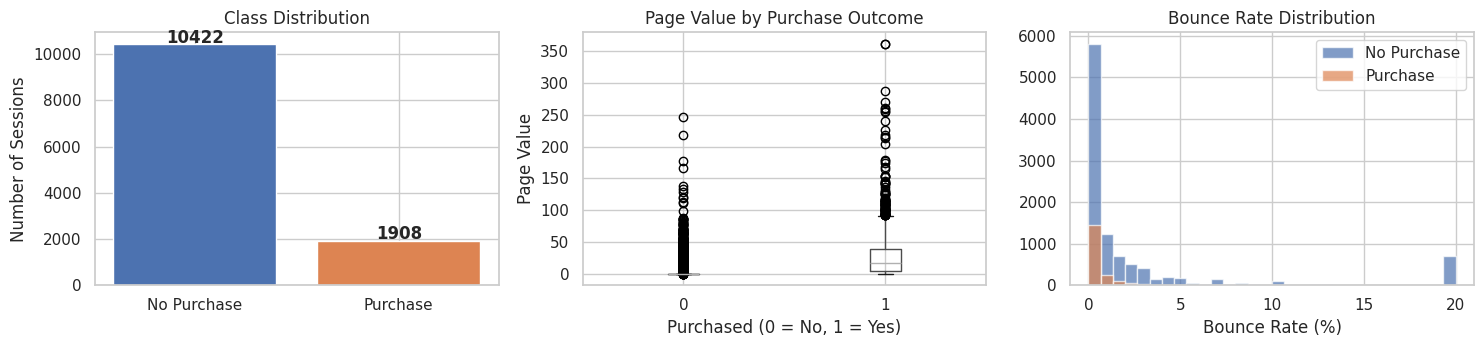

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

purchase_counts = df['Purchased'].value_counts().sort_index()
axes[0].bar(['No Purchase', 'Purchase'], purchase_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Sessions')
for i, v in enumerate(purchase_counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')

df.boxplot(column='Page_Value', by='Purchased', ax=axes[1])
axes[1].set_title('Page Value by Purchase Outcome')
axes[1].set_xlabel('Purchased (0 = No, 1 = Yes)')
axes[1].set_ylabel('Page Value')
plt.sca(axes[1]); plt.title('Page Value by Purchase Outcome')

axes[2].hist(df[df['Purchased']==0]['Bounce_Rate'], bins=30, alpha=0.7,
             label='No Purchase', color='#4C72B0')
axes[2].hist(df[df['Purchased']==1]['Bounce_Rate'], bins=30, alpha=0.7,
             label='Purchase', color='#DD8452')
axes[2].set_title('Bounce Rate Distribution')
axes[2].set_xlabel('Bounce Rate (%)')
axes[2].legend()

plt.tight_layout()
plt.suptitle('')
plt.show()

## 📦 Part 2: Training a Decision Tree Classifier

A **Decision Tree** learns a set of if-else rules to classify data. It starts with all data and repeatedly splits on the feature that best separates the classes.

> 🎯 **Task:** Split the data into training and test sets, train a Decision Tree, and visualize what it learned.

In [21]:
FEATURES = ['Product_Pages', 'Time_on_Site_min', 'Bounce_Rate', 'Page_Value',
            'Special_Day', 'Is_Weekend', 'Returning_Visitor', 'Month']

X = df[FEATURES]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples     : {len(X_train):,}")
print(f"Test samples         : {len(X_test):,}")
print(f"Purchase rate (train): {y_train.mean():.1%}")
print(f"Purchase rate (test) : {y_test.mean():.1%}")

Training samples     : 9,864
Test samples         : 2,466
Purchase rate (train): 15.5%
Purchase rate (test) : 15.5%


In [22]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

print(f"Training accuracy: {tree.score(X_train, y_train):.1%}")
print(f"Test accuracy    : {tree.score(X_test,  y_test):.1%}")

Training accuracy: 89.9%
Test accuracy    : 88.6%


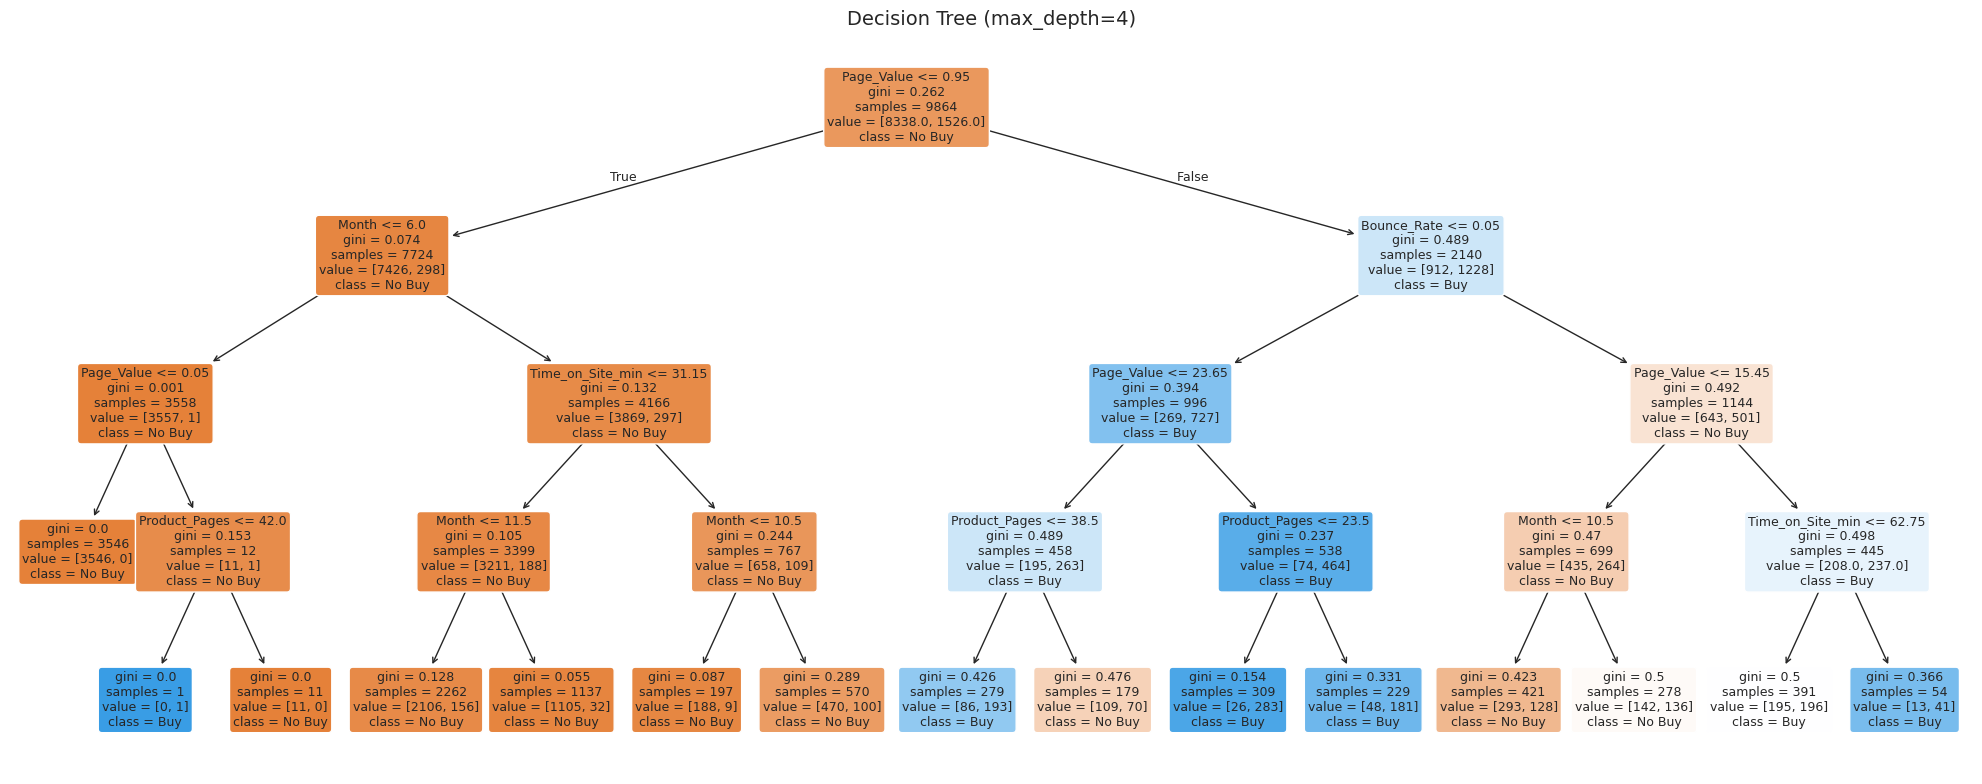

In [23]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree, feature_names=FEATURES, class_names=['No Buy', 'Buy'],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title("Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()

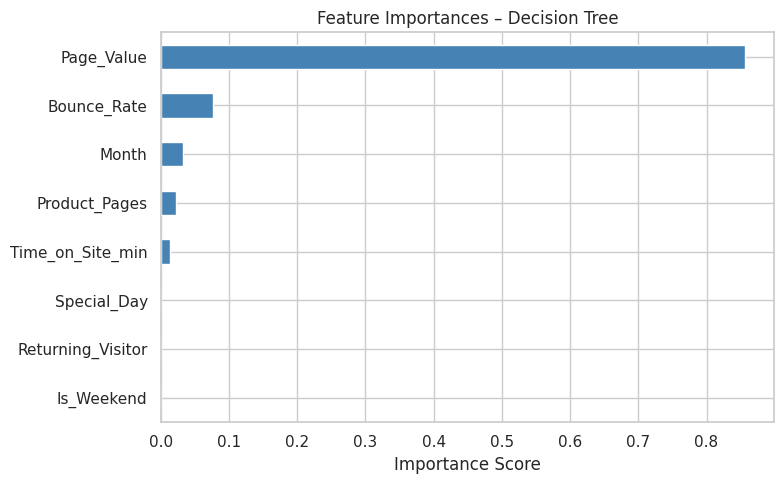

Most important feature: Page_Value


In [24]:
importances = pd.Series(tree.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importances – Decision Tree')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f"Most important feature: {importances.idxmax()}")

## 📦 Part 3: Evaluating with the Confusion Matrix

Accuracy alone can be misleading — especially when classes are **imbalanced** (here: ~84% no-purchase vs ~16% purchase).

The **Confusion Matrix** gives us the full picture:

|  | Predicted: No Purchase | Predicted: Purchase |
|---|---|---|
| **Actual: No Purchase** | ✅ True Negative (TN) | ❌ False Positive (FP) |
| **Actual: Purchase** | ❌ False Negative (FN) | ✅ True Positive (TP) |

From these we derive:
- **Accuracy** = (TP + TN) / Total — how often we're right overall
- **Precision** = TP / (TP + FP) — of predicted purchases, how many were real?
- **Recall** = TP / (TP + FN) — of actual purchases, how many did we catch?

> 🎯 **Task:** Generate the confusion matrix and compute all three metrics for our Decision Tree.

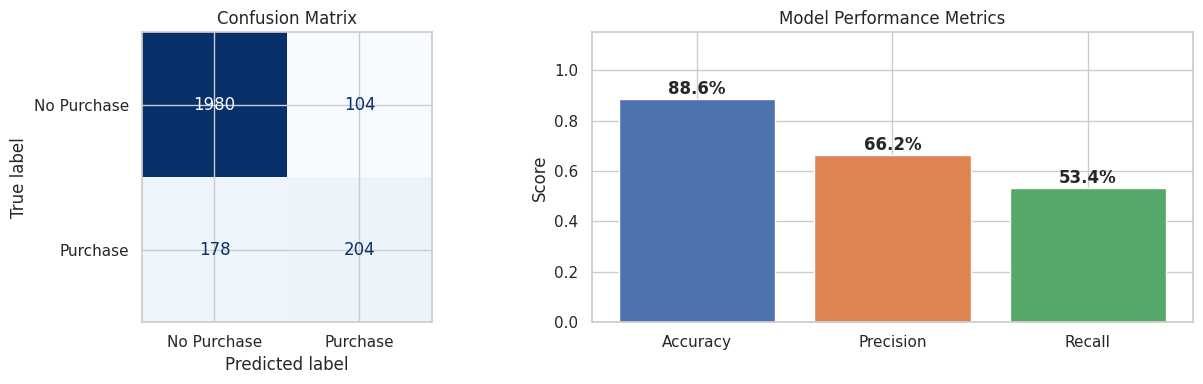

TP=204  TN=1980  FP=104  FN=178


In [25]:
y_pred = tree.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
}
bars = axes[1].bar(metrics.keys(), metrics.values(), color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Model Performance Metrics')
axes[1].set_ylabel('Score')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")

---

> ✏️ **Exercise 1:** Change `max_depth` in Part 2 to `3`, `5`, and `8`. Re-run Parts 2 and 3. What happens to train vs. test accuracy? What does this tell you about **overfitting**?

**Your observations:**

*(Write your answer here)*

## 📦 Part 4: k-Means Clustering on Mall Customer Data

Now we switch gears — from **supervised** (labelled data, predict a class) to **unsupervised** (no labels, discover hidden structure).

We'll use the **Mall Customers dataset** — 200 shoppers described by age, annual income, and spending score. The goal: find natural customer segments that could inform a targeted marketing strategy.

**Key difference from Part 1–3:**
- There is **no target column** — we don't tell the algorithm what groups to find
- The algorithm discovers structure purely from patterns in the data

> 🎯 **Task:** Explore the data, use the Elbow Method to choose k, run k-Means, and interpret what each cluster represents.

In [26]:
ds_mall = load_dataset('ankislyakov/mall_customers', split='train')
df_mall = ds_mall.to_pandas()

print(f"Shape: {df_mall.shape}")
print(f"\nBasic statistics:")
print(df_mall[['age', 'annual_income', 'spending_score']].describe().round(1).to_string())
df_mall.head()

Shape: (200, 5)

Basic statistics:
         age  annual_income  spending_score
count  200.0          200.0           200.0
mean    38.8           60.6            50.2
std     14.0           26.3            25.8
min     18.0           15.0             1.0
25%     28.8           41.5            34.8
50%     36.0           61.5            50.0
75%     49.0           78.0            73.0
max     70.0          137.0            99.0


,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


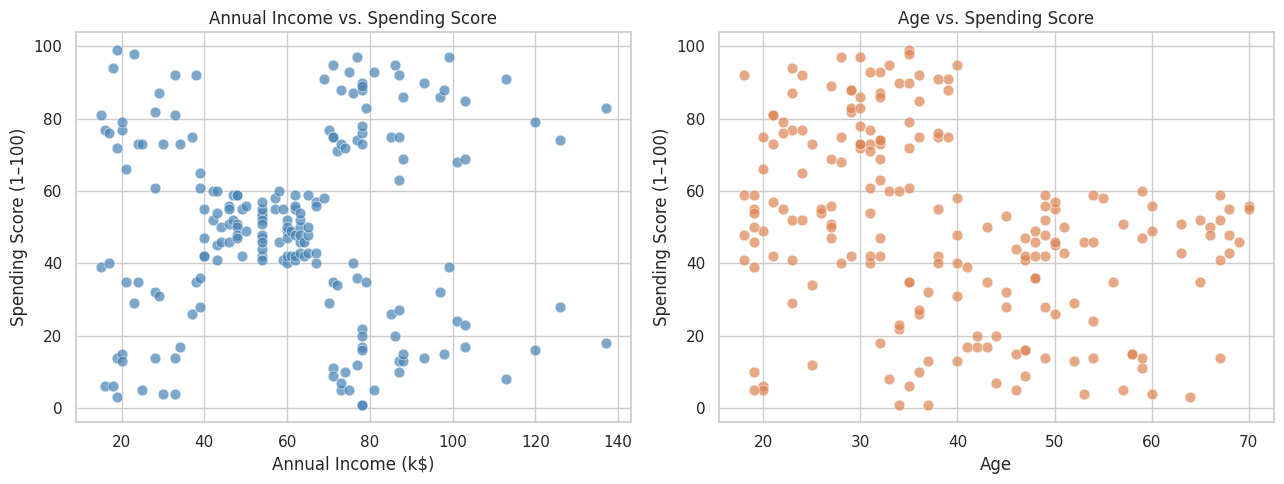

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_mall['annual_income'], df_mall['spending_score'],
                alpha=0.7, color='steelblue', s=60, edgecolors='white', linewidths=0.5)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1–100)')
axes[0].set_title('Annual Income vs. Spending Score')

axes[1].scatter(df_mall['age'], df_mall['spending_score'],
                alpha=0.7, color='#DD8452', s=60, edgecolors='white', linewidths=0.5)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score (1–100)')
axes[1].set_title('Age vs. Spending Score')

plt.tight_layout()
plt.show()

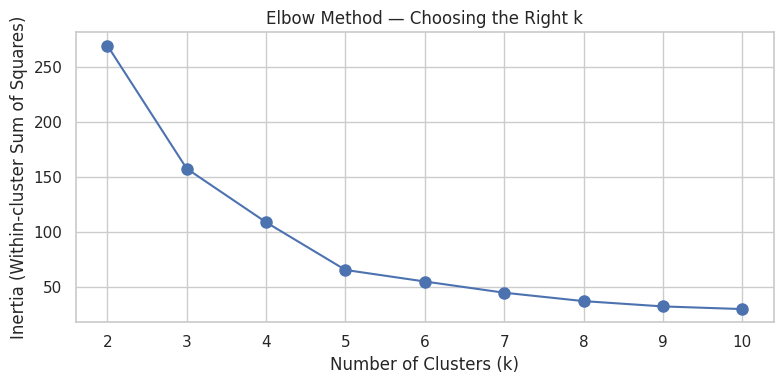

In [28]:
X_mall = df_mall[['annual_income', 'spending_score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mall)

inertias = []
K_range  = range(2, 11)

for k in K_range:
    km_try = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_try.fit(X_scaled)
    inertias.append(km_try.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method — Choosing the Right k')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

In [29]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
km.fit(X_scaled)

df_mall['cluster'] = km.labels_

print("Customers per cluster:")
print(pd.Series(km.labels_).value_counts().sort_index().to_string())

Customers per cluster:
0    81
1    39
2    22
3    35
4    23


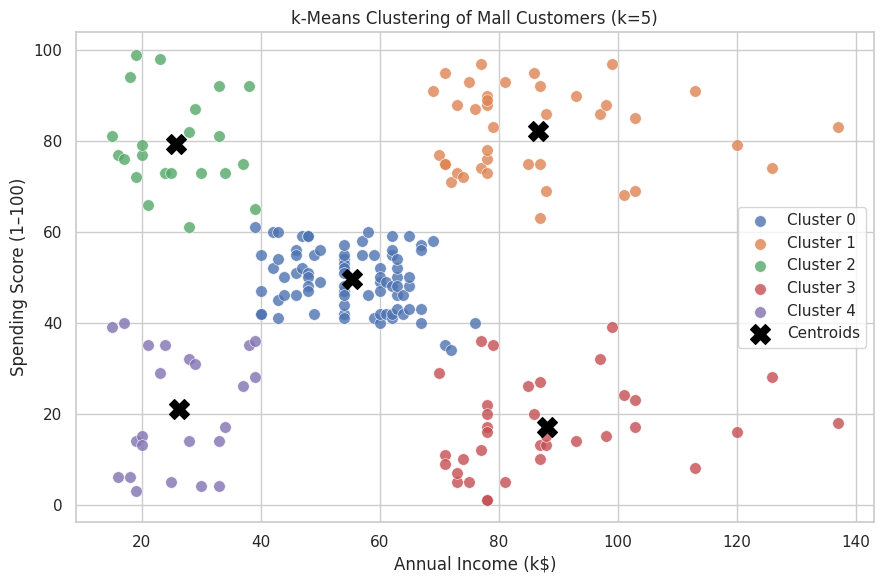

In [30]:
cluster_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(5):
    mask = df_mall['cluster'] == c
    ax.scatter(df_mall.loc[mask, 'annual_income'], df_mall.loc[mask, 'spending_score'],
               label=f'Cluster {c}', alpha=0.8, s=70,
               color=cluster_colors[c], edgecolors='white', linewidths=0.5)

centroids_orig = scaler.inverse_transform(km.cluster_centers_)
ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
           marker='X', s=200, color='black', zorder=5, label='Centroids')

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1–100)')
ax.set_title('k-Means Clustering of Mall Customers (k=5)')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
profile = df_mall.groupby('cluster')[['annual_income', 'spending_score', 'age']].mean().round(1)
profile.columns = ['Avg Income (k$)', 'Avg Spending Score', 'Avg Age']
print("Cluster Profiles:")
print(profile.to_string())

Cluster Profiles:
         Avg Income (k$)  Avg Spending Score  Avg Age
cluster                                              
0                   55.3                49.5     42.7
1                   86.5                82.1     32.7
2                   25.7                79.4     25.3
3                   88.2                17.1     41.1
4                   26.3                20.9     45.2


---

> ✏️ **Exercise 2:** Look at the cluster plot and the profile table. Give each cluster a descriptive name (e.g., "Careful Savers", "Luxury Shoppers").

| Cluster | Avg Income | Avg Spending | Suggested Name |
|---|---|---|---|
| 0 | ~55 k$ | ~50 | |
| 1 | ~87 k$ | ~82 | |
| 2 | ~26 k$ | ~79 | |
| 3 | ~88 k$ | ~17 | |
| 4 | ~26 k$ | ~21 | |

**Which cluster should the mall target for premium promotions? Why?**

*(Write your answer here)*

## 📦 Part 5: Classification vs. Clustering — Side-by-Side

| | Decision Tree | k-Means |
|---|---|---|
| **Learning type** | Supervised | Unsupervised |
| **Labels needed?** | ✅ Yes | ❌ No |
| **Goal** | Predict a known category | Discover hidden groups |
| **Evaluation** | Accuracy, Precision, Recall | Inertia, visual inspection |
| **Output** | Class prediction for new data | Cluster assignment |
| **Dataset used today** | UCI Online Shoppers (12,330 sessions) | Mall Customers (200 shoppers) |

**Key insight:** k-Means found meaningful customer segments **without any labels**. The business doesn't need to pre-define what a "good customer" is — the algorithm finds the natural groups.

## 📦 Part 6: Group Activity

Each group works on a different real-world dataset using the techniques from today.

| Group | Dataset | Task | Key challenge |
|---|---|---|---|
| 🔵 Blue | Palmer Penguins | **k-Means** — discover species | Can clustering find 3 species without labels? |
| 🟠 Orange | Wine Quality | **Decision Tree** — classify good vs poor | Which chemical properties predict quality? |
| 🟢 Green | Breast Cancer | **Decision Tree** — classify tumours | When does Recall matter more than Precision? |
| 🟣 Purple | Spotify Tracks | **k-Means** — discover music genres | Do audio features group into recognisable genres? |

> 🎯 **Task:** Work through your group's scaffold below. Discuss your results and prepare a 2-minute summary for the class.

### 🔵 Blue Team — Palmer Penguins: k-Means Clustering

**Dataset:** 344 penguins from 3 species (Adelie, Gentoo, Chinstrap), measured on bill length, bill depth, flipper length, and body mass.

**Question:** Can k-Means discover the 3 species *without ever seeing the species labels*?

**Hints:**
- Drop rows with missing values before clustering
- Standardise features (bill sizes and body mass are on different scales)
- Try the Elbow Method: does it suggest k=3?
- After clustering, compare your cluster plot to a plot coloured by true species

In [ ]:
# --- 🔵 Blue Team: Palmer Penguins — k-Means ---

ds_penguins = load_dataset('SIH/palmer-penguins', split='train')
df_penguins = ds_penguins.to_pandas()

FEATURES_P = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_penguins = df_penguins.dropna(subset=FEATURES_P).reset_index(drop=True)

print(f"Shape after dropping nulls: {df_penguins.shape}")
print(f"Species counts: {df_penguins['species'].value_counts().to_dict()}")

# --- Step 1: Standardise ---
# X_p = df_penguins[FEATURES_P].values
# scaler_p = StandardScaler()
# X_p_scaled = scaler_p.fit_transform(X_p)

# --- Step 2: Elbow Method ---
# inertias_p = []
# for k in range(2, 8):
#     ...

# --- Step 3: Fit k-Means with k=3 ---
# km_p = KMeans(n_clusters=3, random_state=42, n_init=10)
# km_p.fit(X_p_scaled)
# df_penguins['cluster'] = km_p.labels_

# --- Step 4: Plot clusters vs. true species side-by-side ---
# (use bill_length_mm vs flipper_length_mm as axes)

### 🟠 Orange Team — Wine Quality: Decision Tree

**Dataset:** 1,599 red wine samples with 11 chemical measurements. Quality is rated 3–8.

**Question:** Which chemical properties best predict whether a wine is "good" (quality ≥ 6)?

**Hints:**
- Binarise the target: `quality >= 6` → 1 (Good), `quality < 6` → 0 (Poor)
- All 11 chemical features are numeric — no preprocessing needed
- Look at feature importances: which chemicals matter most?
- Try adjusting `max_depth` — does the tree overfit?

In [ ]:
# --- 🟠 Orange Team: Wine Quality — Decision Tree ---

ds_wine = load_dataset('codesignal/wine-quality', split='red')
df_wine = ds_wine.to_pandas()

# Binarise: good wine = quality 6 or above
df_wine['good_wine'] = (df_wine['quality'] >= 6).astype(int)
FEATURES_W = [c for c in df_wine.columns if c not in ['quality', 'good_wine']]

print(f"Shape: {df_wine.shape}")
print(f"Good wine rate: {df_wine['good_wine'].mean():.1%}")
print(f"Features: {FEATURES_W}")

# --- Step 1: Define X, y ---
# X_w = df_wine[FEATURES_W]
# y_w = df_wine['good_wine']

# --- Step 2: Train/test split ---
# X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(...)

# --- Step 3: Fit Decision Tree ---
# tree_w = DecisionTreeClassifier(max_depth=4, random_state=42)
# tree_w.fit(X_w_train, y_w_train)

# --- Step 4: Confusion matrix + metrics ---

# --- Step 5: Feature importance plot ---

### 🟢 Green Team — Breast Cancer: Decision Tree

**Dataset:** 569 tumour measurements. Diagnosis is Benign (B) or Malignant (M).

**Question:** Can a Decision Tree reliably classify tumours — and which metric matters most in medicine?

**Hints:**
- Drop columns `id` and `Unnamed: 32` (they contain no useful information)
- Convert `diagnosis`: M → 1 (Malignant), B → 0 (Benign)
- After evaluating, discuss: in a cancer screening tool, is **Recall** or **Precision** more important?
  - False Negative = missed cancer; False Positive = unnecessary follow-up

In [ ]:
# --- 🟢 Green Team: Breast Cancer — Decision Tree ---

ds_bc = load_dataset('scikit-learn/breast-cancer-wisconsin', split='train')
df_bc = ds_bc.to_pandas().drop(columns=['id', 'Unnamed: 32'])

df_bc['label'] = (df_bc['diagnosis'] == 'M').astype(int)
FEATURES_BC = [c for c in df_bc.columns if c not in ['diagnosis', 'label']]

print(f"Shape: {df_bc.shape}")
print(f"Malignant rate: {df_bc['label'].mean():.1%}")
print(f"Number of features: {len(FEATURES_BC)}")

# --- Step 1: Define X, y ---
# X_bc = df_bc[FEATURES_BC]
# y_bc = df_bc['label']

# --- Step 2: Train/test split ---
# X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(...)

# --- Step 3: Fit Decision Tree ---
# tree_bc = DecisionTreeClassifier(max_depth=4, random_state=42)
# tree_bc.fit(X_bc_train, y_bc_train)

# --- Step 4: Confusion matrix + metrics ---

# --- Discussion: Should you prioritise Precision or Recall here? ---

### 🟣 Purple Team — Spotify Tracks: k-Means Clustering

**Dataset:** 114,000 Spotify tracks across 114 genres, each described by audio features like energy, danceability, and acousticness.

**Question:** If you cluster tracks purely by their sound — no genre labels — do meaningful music categories emerge?

**Hints:**
- Filter to 5 contrasting genres and use the full 1,000 tracks per genre
- Features like `loudness` are on a very different scale — standardise first
- Does the Elbow Method suggest k=5?
- After clustering, make a genre × cluster crosstab: which genres are "cleanest"?
- Plot clusters on `energy` vs `danceability` — a classic Spotify 2D view

In [ ]:
# --- 🟣 Purple Team: Spotify Tracks — k-Means ---

GENRES_S = ['acoustic', 'electronic', 'hip-hop', 'classical', 'metal']

ds_spotify = load_dataset('maharshipandya/spotify-tracks-dataset', split='train')
df_spotify = ds_spotify.to_pandas()
df_spotify = df_spotify[df_spotify['track_genre'].isin(GENRES_S)].reset_index(drop=True)

FEATURES_S = ['danceability', 'energy', 'loudness', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

print(f"Shape: {df_spotify.shape}")
print(f"Tracks per genre: {df_spotify['track_genre'].value_counts().to_dict()}")

# --- Step 1: Standardise ---
# X_s = df_spotify[FEATURES_S].values
# scaler_s = StandardScaler()
# X_s_scaled = scaler_s.fit_transform(X_s)

# --- Step 2: Elbow Method (k = 2..8) ---
# inertias_s = []
# for k in range(2, 9):
#     ...

# --- Step 3: Fit k-Means with k=5 ---
# km_s = KMeans(n_clusters=5, random_state=42, n_init=10)
# km_s.fit(X_s_scaled)
# df_spotify['cluster'] = km_s.labels_

# --- Step 4: Cluster profiles ---
# print(df_spotify.groupby('cluster')[FEATURES_S].mean().round(2))

# --- Step 5: Genre × cluster crosstab ---
# print(pd.crosstab(df_spotify['cluster'], df_spotify['track_genre']))

# --- Step 6: Scatter plot — energy vs danceability, coloured by cluster ---
# (add a second plot coloured by true genre for comparison)

## 📦 Bonus: Ensemble Methods

A single Decision Tree can overfit. **Ensemble methods** combine many trees for better generalisation:

- **Random Forest**: trains many trees on random subsets of data and features, then votes
- **Gradient Boosting**: trains trees sequentially, each correcting the previous one's errors

> 🎯 **Task:** Train both ensemble models on the UCI data and compare them with the single Decision Tree.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

models = {
    'Decision Tree (depth=4)'    : tree,
    'Random Forest (100 trees)'  : rf,
    'Gradient Boosting (100 tr.)': gb,
}

print(f"{'Model':<32} {'Train':>8} {'Test':>8} {'Precision':>10} {'Recall':>8}")
print('-' * 70)
for name, model in models.items():
    yp = model.predict(X_test)
    print(f"{name:<32} {model.score(X_train, y_train):>8.1%} "
          f"{accuracy_score(y_test, yp):>8.1%} "
          f"{precision_score(y_test, yp):>10.1%} "
          f"{recall_score(y_test, yp):>8.1%}")

In [ ]:
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
rf_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 💬 Class Discussion

Take a few minutes to discuss with your neighbours:

1. **Decision Tree (UCI Shoppers):** What was the most important feature for predicting purchases? Does this make business sense?

2. **Confusion Matrix:** If you were the e-commerce manager, would you rather minimise False Positives (wasted marketing) or False Negatives (missed buyers)?

3. **k-Means (Mall Customers):** Which cluster should the mall target for premium promotions? How would you market differently to each group?

4. **Group Activity:** Compare across the four groups — which dataset had the clearest clusters or decision boundaries? Which metric (Accuracy, Precision, Recall) mattered most for each domain?

## ✅ Session Summary

By the end of this session you should be able to:

- [ ] 🌳 Train a **Decision Tree** classifier and read its rules
- [ ] 📊 Interpret a **Confusion Matrix** (TP, TN, FP, FN)
- [ ] 📐 Compute and explain **Accuracy, Precision, and Recall**
- [ ] 📏 Explain why we **standardise** features before k-Means
- [ ] 🔍 Apply **k-Means clustering** and choose k with the **Elbow Method**
- [ ] 🗺️ Visualise and **interpret clusters** in business terms
- [ ] 🌲 Explain why **Ensemble Methods** outperform single trees
- [ ] ⚖️ Explain the difference between **supervised** and **unsupervised** learning